# 🏥 Healthcare Analytics Using Python

## End-to-End Healthcare Data Analysis Project

### 📌 Business Objective

The objective of this project is to analyze hospital operations by integrating patient, doctor, appointment, treatment, and billing datasets. The project identifies business insights related to patient demographics, doctor workload, treatment costs, hospital revenue, and payment performance to support data-driven decision-making.

---

### 🛠️ Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 2. Load Datasets

In [4]:
patients = pd.read_csv("../Dataset/patients.csv")
doctors = pd.read_csv("../Dataset/doctors.csv")
appointments = pd.read_csv("../Dataset/appointments.csv")
treatments = pd.read_csv("../Dataset/treatments.csv")
billing = pd.read_csv("../Dataset/billing.csv")

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the structure, quality, and characteristics of the datasets before performing data cleaning and analysis.

In [5]:
print("Patients Dataset")
patients.info()

print("\nDoctors Dataset")
doctors.info()

print("\nAppointments Dataset")
appointments.info()

print("\nTreatments Dataset")
treatments.info()

print("\nBilling Dataset")
billing.info()

Patients Dataset
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          50 non-null     str  
 1   first_name          50 non-null     str  
 2   last_name           50 non-null     str  
 3   gender              50 non-null     str  
 4   date_of_birth       50 non-null     str  
 5   contact_number      50 non-null     int64
 6   address             50 non-null     str  
 7   registration_date   50 non-null     str  
 8   insurance_provider  50 non-null     str  
 9   insurance_number    50 non-null     str  
 10  email               50 non-null     str  
dtypes: int64(1), str(10)
memory usage: 4.4 KB

Doctors Dataset
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   doctor_id         10 non-null  

In [6]:
print("Missing Values in Patients")
print(patients.isnull().sum())

print("\nMissing Values in Doctors")
print(doctors.isnull().sum())

print("\nMissing Values in Appointments")
print(appointments.isnull().sum())

print("\nMissing Values in Treatments")
print(treatments.isnull().sum())

print("\nMissing Values in Billing")
print(billing.isnull().sum())


Missing Values in Patients
patient_id            0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
dtype: int64

Missing Values in Doctors
doctor_id           0
first_name          0
last_name           0
specialization      0
phone_number        0
years_experience    0
hospital_branch     0
email               0
dtype: int64

Missing Values in Appointments
appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
reason_for_visit    0
status              0
dtype: int64

Missing Values in Treatments
treatment_id      0
appointment_id    0
treatment_type    0
description       0
cost              0
treatment_date    0
dtype: int64

Missing Values in Billing
bill_id           0
patient_id        0
treatment_id      0
bill_date         0
amount     

In [7]:
print("Patients Duplicates :", patients.duplicated().sum())
print("Doctors Duplicates :", doctors.duplicated().sum())
print("Appointments Duplicates :", appointments.duplicated().sum())
print("Treatments Duplicates :", treatments.duplicated().sum())
print("Billing Duplicates :", billing.duplicated().sum())

Patients Duplicates : 0
Doctors Duplicates : 0
Appointments Duplicates : 0
Treatments Duplicates : 0
Billing Duplicates : 0


## 4. Feature Engineering

A new feature, **Age**, was created from the patient's date of birth to support demographic analysis.

In [8]:
# Convert Date of Birth to Date Format
patients["date_of_birth"] = pd.to_datetime(patients["date_of_birth"])

# Current Date
today = pd.Timestamp.today()

# Calculate Age
patients["Age"] = (
    (today.year - patients["date_of_birth"].dt.year)
    - (
        (today.month < patients["date_of_birth"].dt.month)
        | (
            (today.month == patients["date_of_birth"].dt.month)
            & (today.day < patients["date_of_birth"].dt.day)
        )
    )
)

In [9]:
patients[["first_name", "last_name", "Age"]].head()

,first_name,last_name,Age
0,David,Williams,71
1,Emily,Smith,41
2,Laura,Jones,48
3,Michael,Johnson,45
4,David,Wilson,66


## 5. Data Integration

The individual datasets were integrated using common keys (`patient_id`, `doctor_id`, `appointment_id`, and `treatment_id`) to create a unified healthcare dataset for analysis.

In [10]:
# Merge Patients and Appointments
patient_appointments = pd.merge(
    patients,
    appointments,
    on="patient_id",
    how="inner"
)

# Merge Doctors
hospital_data = pd.merge(
    patient_appointments,
    doctors,
    on="doctor_id",
    how="inner"
)

# Merge Treatments
hospital_data = pd.merge(
    hospital_data,
    treatments,
    on="appointment_id",
    how="inner"
)

# Merge Billing
master_healthcare_data = pd.merge(
    hospital_data,
    billing,
    on="treatment_id",
    how="inner"
)

In [11]:
print("Final Dataset Shape:", master_healthcare_data.shape)

master_healthcare_data.head()

Final Dataset Shape: (200, 36)


,patient_id_x,first_name_x,last_name_x,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,...,treatment_type,description,cost,treatment_date,bill_id,patient_id_y,bill_date,amount,payment_method,payment_status
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,...,Chemotherapy,Advanced protocol,534.03,2023-04-09,B007,P001,2023-04-09,534.03,Cash,Failed
1,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,...,Chemotherapy,Advanced protocol,3249.41,2023-01-16,B048,P001,2023-01-16,3249.41,Credit Card,Failed
2,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,...,ECG,Advanced protocol,2960.14,2023-01-26,B071,P001,2023-01-26,2960.14,Cash,Paid
3,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,...,Physiotherapy,Standard procedure,975.49,2023-04-01,B197,P001,2023-04-01,975.49,Cash,Pending
4,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,...,Physiotherapy,Basic screening,1736.63,2023-10-06,B055,P002,2023-10-06,1736.63,Cash,Failed


### Data Integration Summary

The final dataset combines patient information, doctor details, appointment records, treatment information, and billing data into a single analytical dataset.

This integrated dataset is used for revenue analysis, patient demographics, doctor performance, treatment cost analysis, and payment status evaluation.

# 6. Business Analysis

The integrated healthcare dataset was analyzed to identify key business metrics related to hospital revenue, patient demographics, doctor performance, treatment costs, and payment status.

In [12]:
# Revenue KPIs

total_revenue = master_healthcare_data["amount"].sum()
average_bill = master_healthcare_data["amount"].mean()
highest_bill = master_healthcare_data["amount"].max()
lowest_bill = master_healthcare_data["amount"].min()

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Bill: ₹{average_bill:,.2f}")
print(f"Highest Bill: ₹{highest_bill:,.2f}")
print(f"Lowest Bill: ₹{lowest_bill:,.2f}")

Total Revenue: ₹551,249.85
Average Bill: ₹2,756.25
Highest Bill: ₹4,973.63
Lowest Bill: ₹534.03


In [15]:
print("Total Patients :", master_healthcare_data["patient_id_x"].nunique())

print("Male Patients :", (master_healthcare_data["gender"]=="Male").sum())

print("Female Patients :", (master_healthcare_data["gender"]=="Female").sum())

print("Average Age :", round(master_healthcare_data["Age"].mean(),2))

Total Patients : 48
Male Patients : 0
Female Patients : 0
Average Age : 43.36


## 7. Executive KPI Dashboard

In [16]:
print("=" * 50)
print("🏥 HEALTHCARE ANALYTICS DASHBOARD")
print("=" * 50)

print(f"👤 Total Patients           : {master_healthcare_data['patient_id_x'].nunique()}")
print(f"👨‍⚕️ Total Doctors            : {master_healthcare_data['doctor_id'].nunique()}")
print(f"📅 Total Appointments       : {master_healthcare_data['appointment_id'].nunique()}")
print(f"💊 Total Treatments         : {master_healthcare_data['treatment_id'].nunique()}")
print(f"💰 Total Revenue            : ₹{master_healthcare_data['amount'].sum():,.2f}")
print(f"💵 Average Bill Amount      : ₹{master_healthcare_data['amount'].mean():,.2f}")

🏥 HEALTHCARE ANALYTICS DASHBOARD
👤 Total Patients           : 48
👨‍⚕️ Total Doctors            : 10
📅 Total Appointments       : 200
💊 Total Treatments         : 200
💰 Total Revenue            : ₹551,249.85
💵 Average Bill Amount      : ₹2,756.25


## 8. Data Visualizations

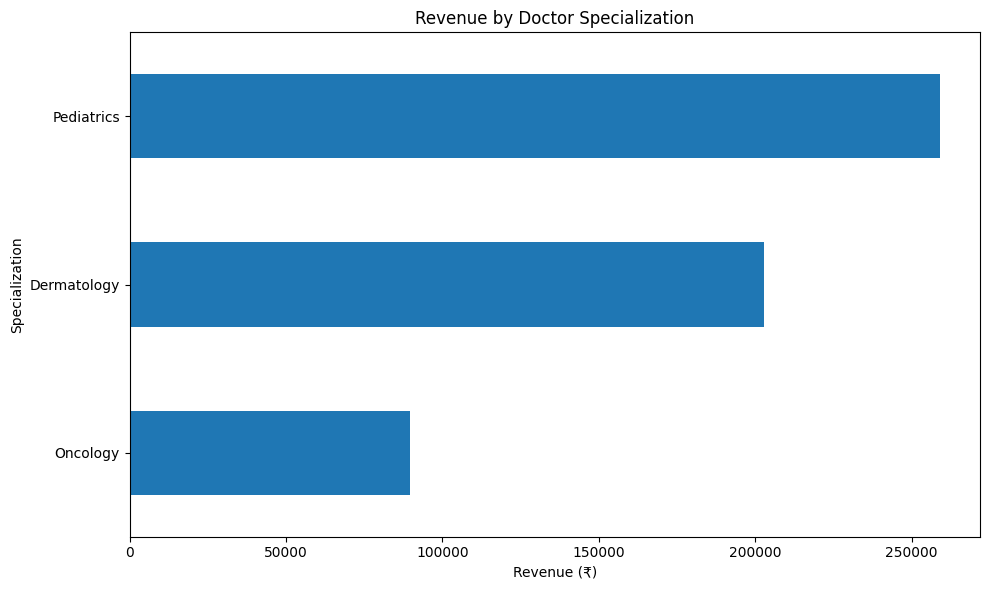

In [21]:
plt.figure(figsize=(10,6))

master_healthcare_data.groupby("specialization")["amount"].sum().sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Doctor Specialization")
plt.xlabel("Revenue (₹)")
plt.ylabel("Specialization")

master_healthcare_data.groupby("specialization")["amount"]\
.sum()\
.sort_values(ascending=False)

plt.tight_layout()
plt.show()

<Axes: xlabel='payment_status'>

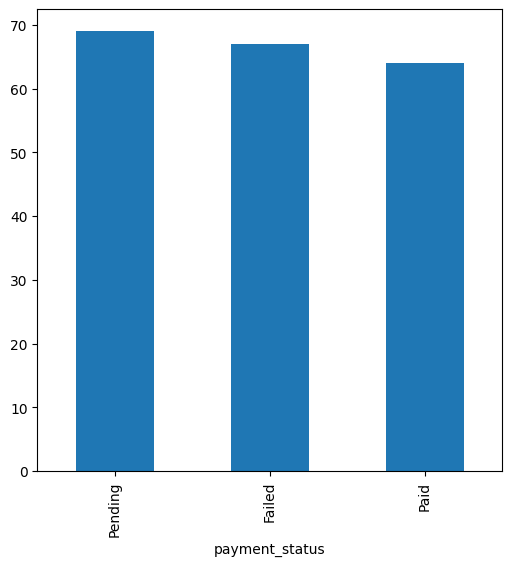

In [24]:
plt.figure(figsize=(6,6))

master_healthcare_data["payment_status"]\
.value_counts()\
.plot(kind="bar")

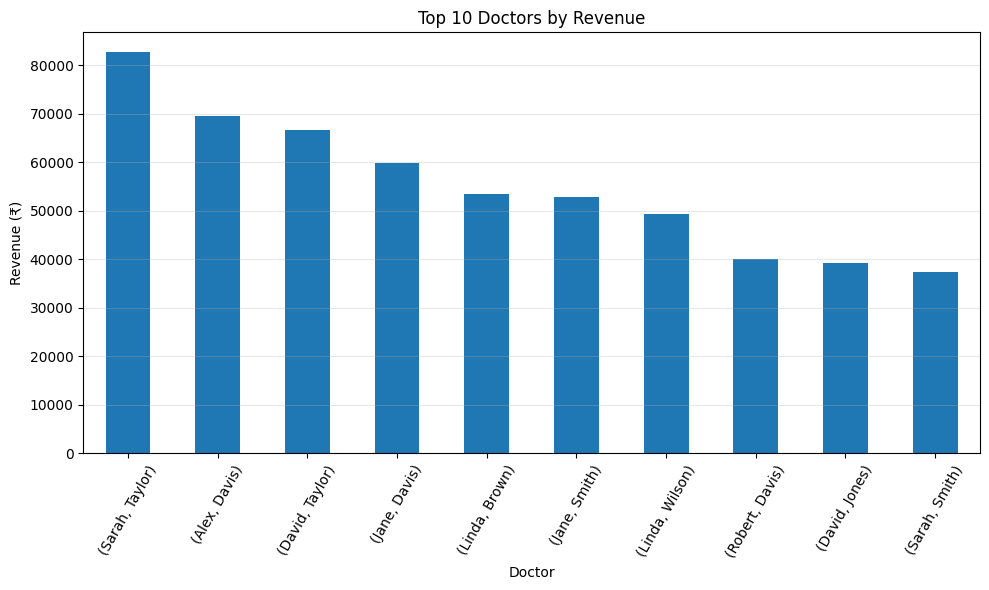

In [25]:
doctor_revenue = (
    master_healthcare_data
    .groupby(["first_name_y", "last_name_y"])["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

doctor_revenue.plot(kind="bar")

plt.title("Top 10 Doctors by Revenue")
plt.xlabel("Doctor")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=60)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

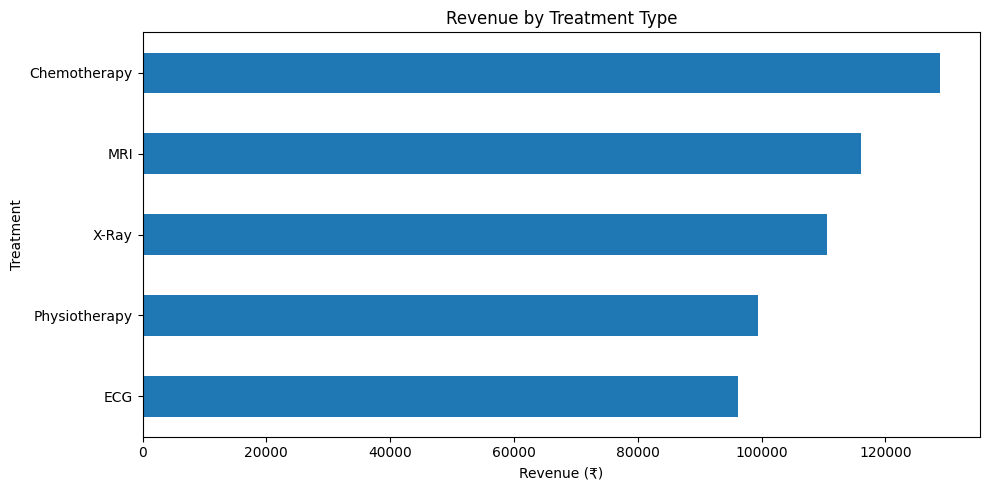

In [20]:
plt.figure(figsize=(10,5))

master_healthcare_data.groupby("treatment_type")["amount"].sum().sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Treatment Type")
plt.xlabel("Revenue (₹)")
plt.ylabel("Treatment")

plt.tight_layout()

plt.show()

### Patient Age Distribution

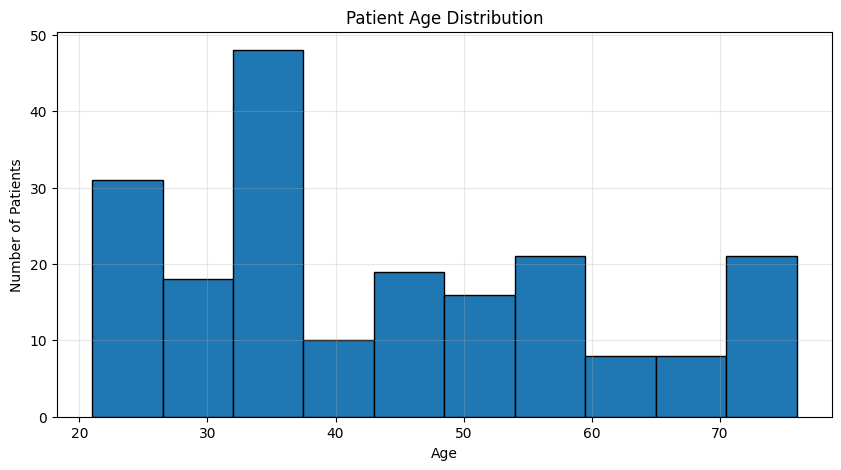

In [26]:
plt.figure(figsize=(10,5))

plt.hist(
    master_healthcare_data["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.grid(alpha=0.3)

plt.show()

### Gender Distribution

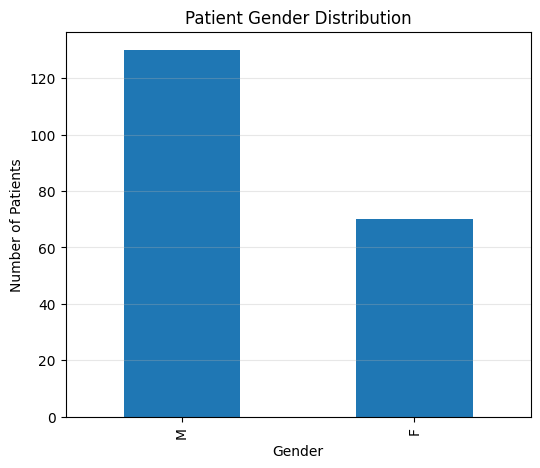

In [27]:
plt.figure(figsize=(6,5))

master_healthcare_data["gender"]\
.value_counts()\
.plot(kind="bar")

plt.title("Patient Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Revenue by Hospital Branch

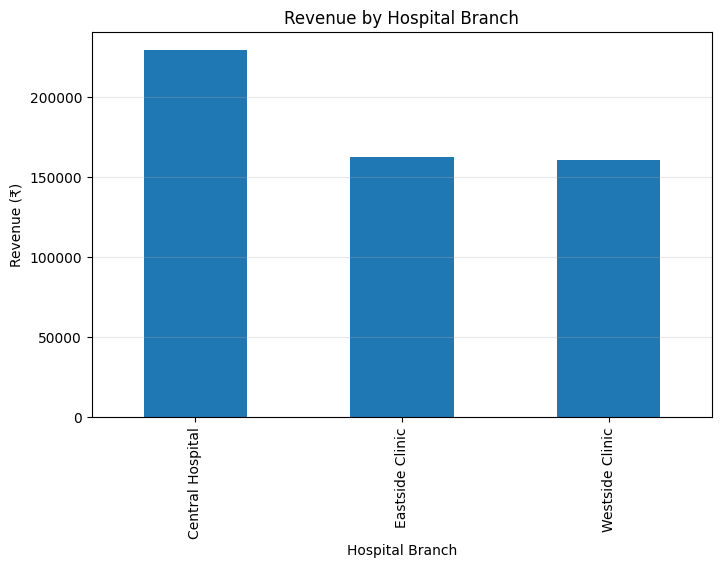

In [28]:
plt.figure(figsize=(8,5))

master_healthcare_data.groupby("hospital_branch")["amount"]\
.sum()\
.sort_values(ascending=False)\
.plot(kind="bar")

plt.title("Revenue by Hospital Branch")
plt.xlabel("Hospital Branch")
plt.ylabel("Revenue (₹)")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Revenue by Payment Method

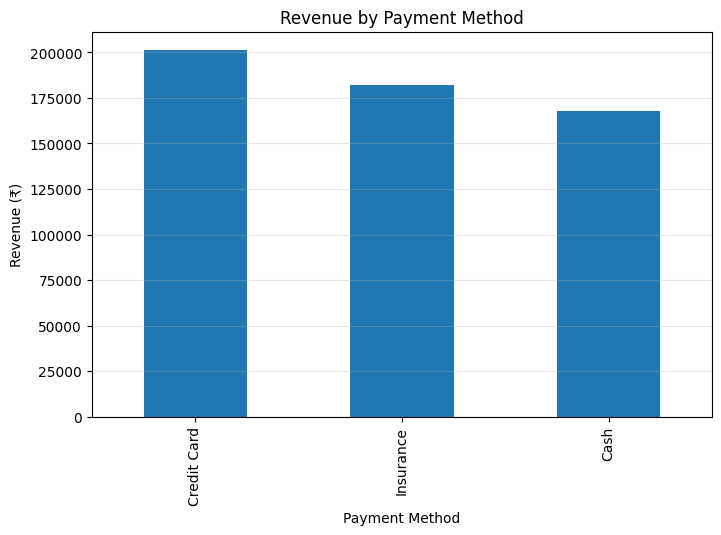

In [29]:
plt.figure(figsize=(8,5))

master_healthcare_data.groupby("payment_method")["amount"]\
.sum()\
.sort_values(ascending=False)\
.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (₹)")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Top Insurance Providers

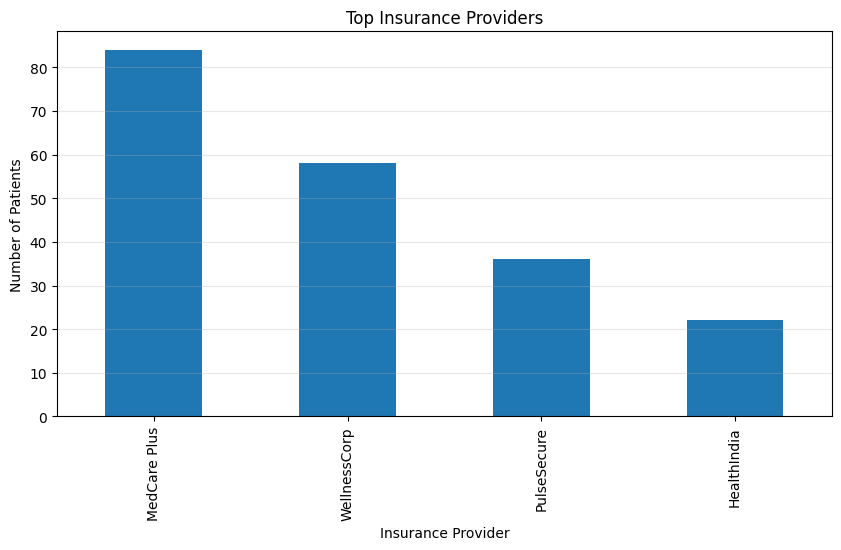

In [30]:
plt.figure(figsize=(10,5))

master_healthcare_data["insurance_provider"]\
.value_counts()\
.plot(kind="bar")

plt.title("Top Insurance Providers")
plt.xlabel("Insurance Provider")
plt.ylabel("Number of Patients")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Appointment Status

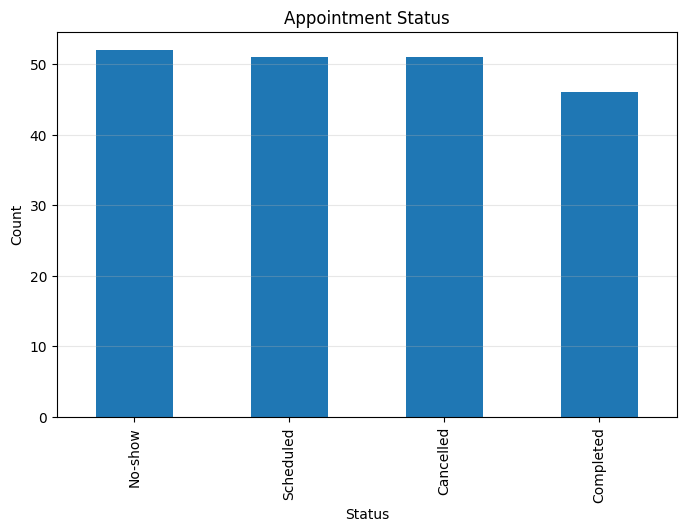

In [31]:
plt.figure(figsize=(8,5))

master_healthcare_data["status"]\
.value_counts()\
.plot(kind="bar")

plt.title("Appointment Status")
plt.xlabel("Status")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

# 9. Key Insights

### Business Insights

- Pediatrics generated the highest hospital revenue among all doctor specializations.

- Chemotherapy was the highest revenue-generating treatment type.

- Nearly one-third of all payments are still pending, indicating opportunities to improve the billing collection process.

- Patient distribution across genders is balanced, providing an unbiased healthcare dataset.

- Revenue is distributed across multiple hospital branches, helping management identify high-performing locations.

- Insurance coverage is widely utilized by patients, indicating strong dependence on insurance providers for healthcare payments.

- Doctor revenue analysis identifies the highest-performing doctors based on treatment revenue.

- Age distribution shows that the hospital serves patients across multiple age groups rather than focusing on a single demographic.

# 10. Business Recommendations

### Recommendations

• Improve payment follow-up procedures to reduce pending payments.

• Increase staffing and resources within the Pediatrics department due to its consistently high revenue contribution.

• Expand high-demand treatment services such as Chemotherapy and MRI.

• Build stronger partnerships with major insurance providers to improve patient experience.

• Monitor doctor performance using revenue and appointment metrics for better resource planning.

• Allocate additional investments to high-performing hospital branches.

• Introduce predictive analytics to forecast patient visits and optimize hospital operations.

# 11. Conclusion

This project demonstrates an end-to-end Healthcare Analytics workflow using Python by integrating multiple healthcare datasets, performing exploratory data analysis, feature engineering, data integration, business KPI analysis, and visualization.

The project provides actionable insights into patient demographics, doctor performance, treatment costs, hospital revenue, and payment trends. These insights can help healthcare organizations improve operational efficiency, financial performance, and strategic decision-making.

The project showcases practical skills in Python, Pandas, NumPy, Matplotlib, Seaborn, and real-world business analytics.